In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/cleaned_healthcare_dataset.csv")

In [3]:
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])

In [4]:

df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,...,Admission Type,Discharge Date,Medication,Test Results,Length of Stay,Senior Citizen,Emergency Admission,Abnormal Test,Risk Score,Risk Category
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons And Miller,Blue Cross,18856.281306,...,Urgent,2024-02-02,Paracetamol,Normal,2,False,False,False,0,Low
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,...,Emergency,2019-08-26,Ibuprofen,Inconclusive,6,False,True,False,1,Medium
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook Plc,Aetna,27955.096079,...,Emergency,2022-10-07,Aspirin,Normal,15,True,True,False,2,High
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers And Vang,",Medicare,37909.782410,...,Elective,2020-12-18,Ibuprofen,Abnormal,30,False,False,True,1,Medium
4,Adrienne Bell,43,Female,Ab+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,...,Urgent,2022-10-09,Penicillin,Abnormal,20,False,False,True,1,Medium


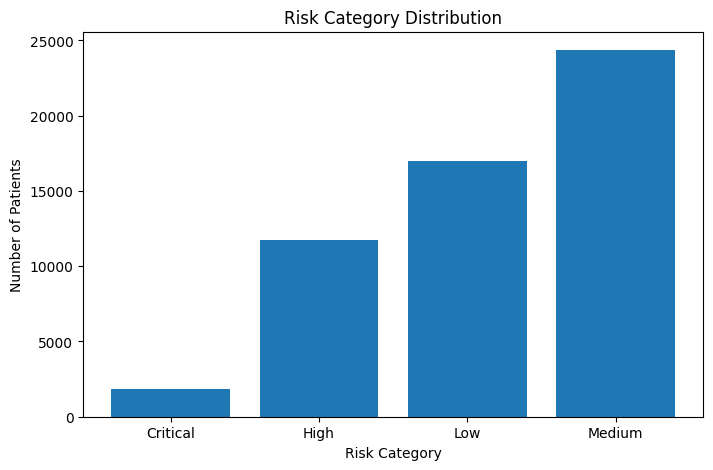

Risk Category
Critical     1868
High        11747
Low         16987
Medium      24364
Name: count, dtype: int64


In [5]:
risk_counts = df["Risk Category"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(risk_counts.index, risk_counts.values)

plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Patients")

plt.show()

print(risk_counts)

In [6]:
high_risk = df[df["Risk Category"].isin(["High", "Critical"])]

print("Total High/Critical Risk Patients:", len(high_risk))

Total High/Critical Risk Patients: 13615


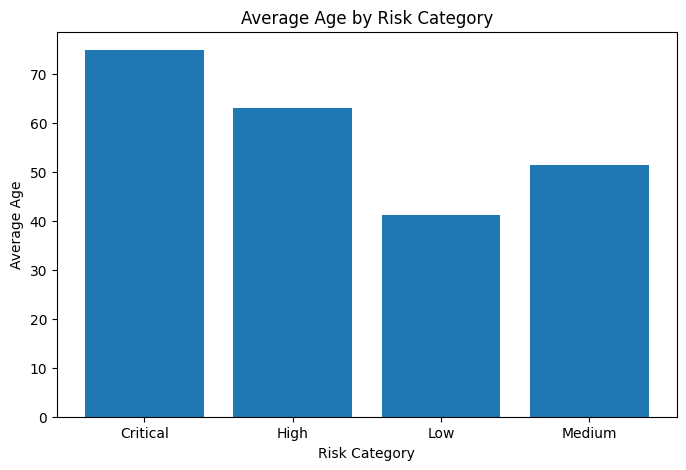

In [7]:
avg_age = df.groupby("Risk Category")["Age"].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_age.index, avg_age.values)

plt.title("Average Age by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Average Age")

plt.show()

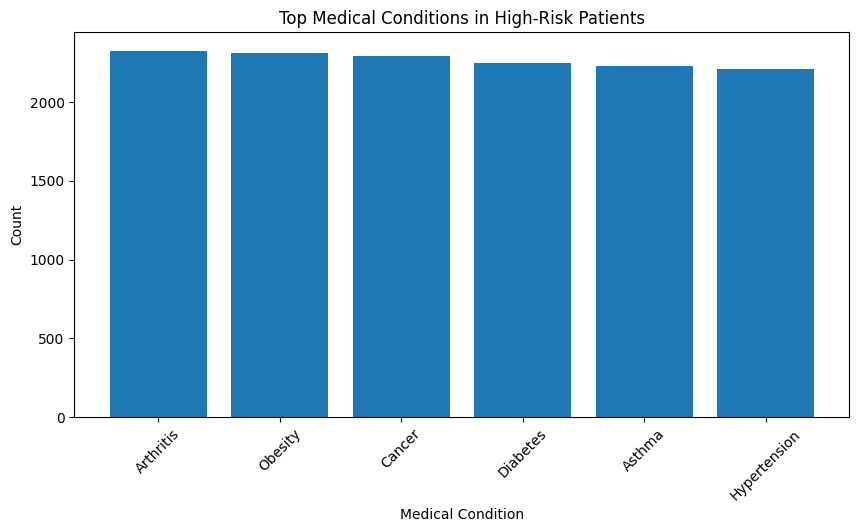

In [8]:
condition_counts = (
    high_risk["Medical Condition"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.bar(condition_counts.index, condition_counts.values)

plt.xticks(rotation=45)
plt.title("Top Medical Conditions in High-Risk Patients")
plt.xlabel("Medical Condition")
plt.ylabel("Count")

plt.show()

In [9]:
risk_admission = pd.crosstab(
    df["Admission Type"],
    df["Risk Category"]
)

print(risk_admission)

Risk Category   Critical  High   Low  Medium
Admission Type                              
Elective               0  1895  8552    8026
Emergency           1868  7944     0    8290
Urgent                 0  1908  8435    8048


In [10]:
test_results = (
    df.groupby("Risk Category")["Abnormal Test"]
    .sum()
)

print(test_results)

Risk Category
Critical    1868
High        7973
Low            0
Medium      8596
Name: Abnormal Test, dtype: int64


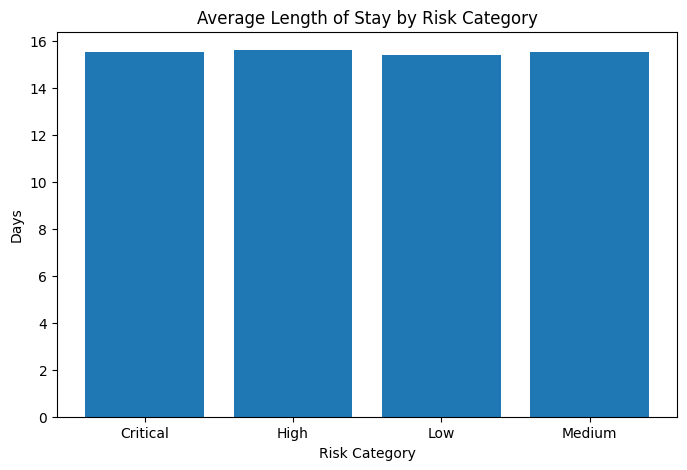

In [12]:
stay = df.groupby("Risk Category")["Length of Stay"].mean()

plt.figure(figsize=(8, 5))
plt.bar(stay.index, stay.values)

plt.title("Average Length of Stay by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Days")

plt.show()

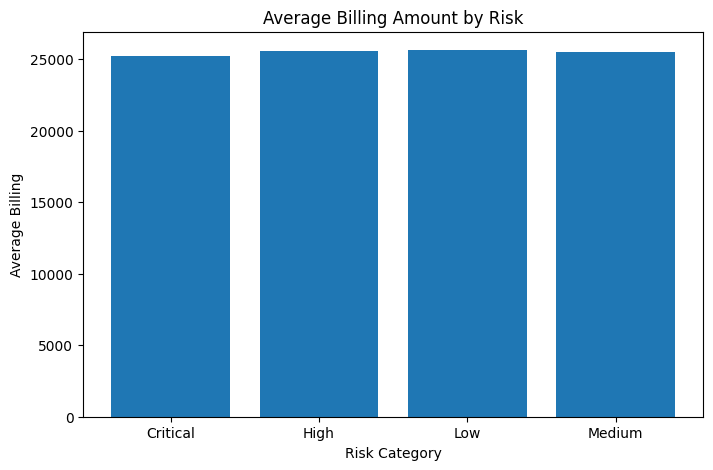

In [13]:
billing = df.groupby("Risk Category")["Billing Amount"].mean()

plt.figure(figsize=(8, 5))
plt.bar(billing.index, billing.values)

plt.title("Average Billing Amount by Risk")
plt.xlabel("Risk Category")
plt.ylabel("Average Billing")

plt.show()

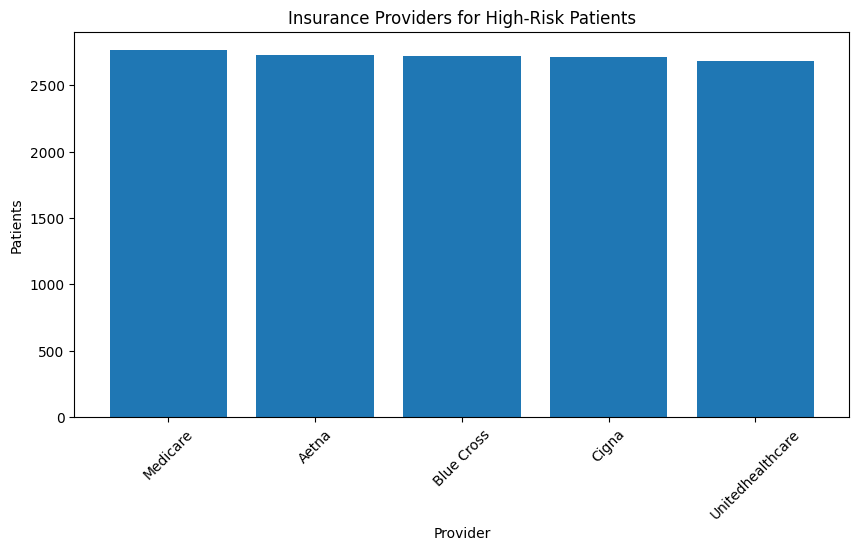

In [14]:
insurance = (
    high_risk["Insurance Provider"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.bar(insurance.index, insurance.values)

plt.xticks(rotation=45)
plt.title("Insurance Providers for High-Risk Patients")
plt.xlabel("Provider")
plt.ylabel("Patients")

plt.show()

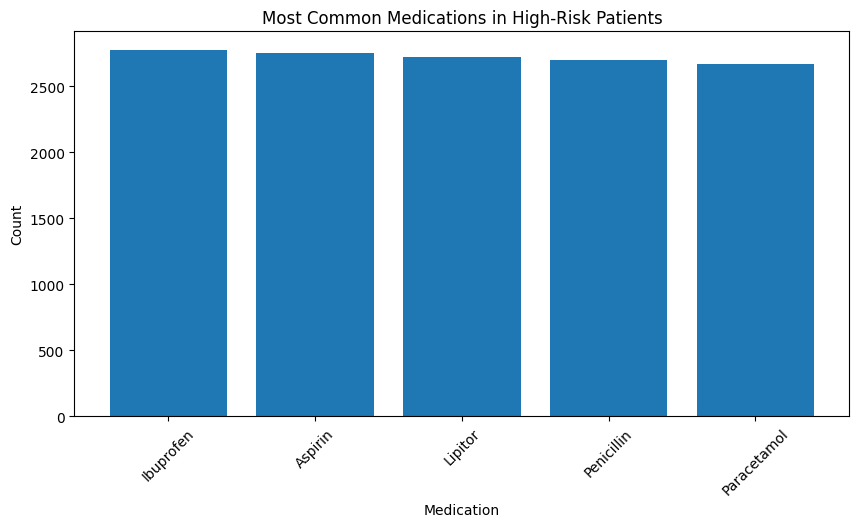

In [15]:
meds = (
    high_risk["Medication"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.bar(meds.index, meds.values)

plt.xticks(rotation=45)
plt.title("Most Common Medications in High-Risk Patients")
plt.xlabel("Medication")
plt.ylabel("Count")

plt.show()

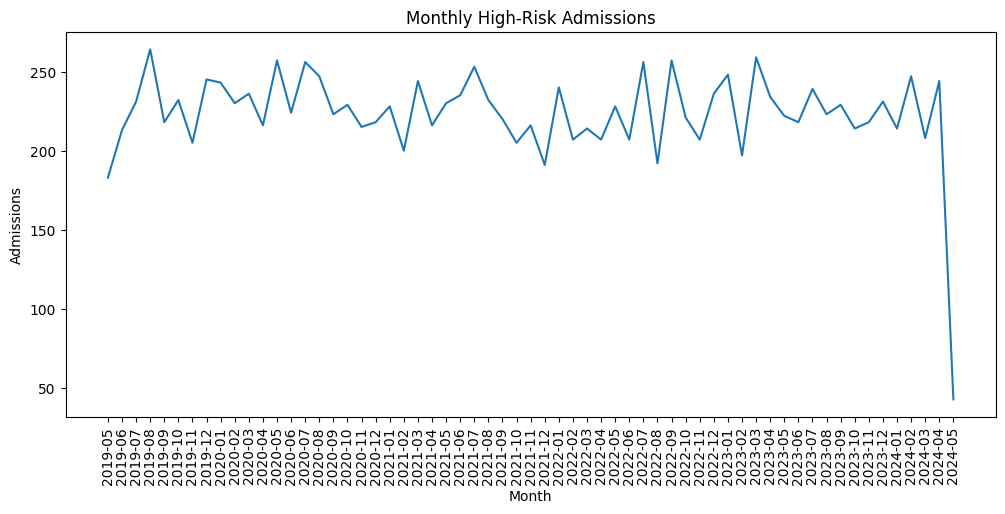

In [16]:
monthly_high = (
    high_risk["Date of Admission"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_high.index.astype(str), monthly_high.values)

plt.xticks(rotation=90)
plt.title("Monthly High-Risk Admissions")
plt.xlabel("Month")
plt.ylabel("Admissions")

plt.show()

In [17]:
print("===== HEALTHCARE RISK SUMMARY =====")
print(f"Total Patients: {len(df)}")
print(f"High/Critical Risk Patients: {len(high_risk)}")
print(f"Average Age: {df['Age'].mean():.2f}")
print(f"Average Length of Stay: {df['Length of Stay'].mean():.2f} days")
print(f"Average Billing Amount: ${df['Billing Amount'].mean():,.2f}")

===== HEALTHCARE RISK SUMMARY =====
Total Patients: 54966
High/Critical Risk Patients: 13615
Average Age: 51.54
Average Length of Stay: 15.50 days
Average Billing Amount: $25,544.31
